# 1D Harmonic Oscillator Physics-Informed Neural Network (PINN)

Solve the **1D damped harmonic oscillator differential equation**:

$$
m \dfrac{d^2 x}{d t^2} + \mu \dfrac{d x}{d t} + kx = 0
$$

With the initial conditions:

$$
x(0) = 1~~,~~\dfrac{d x}{d t} = 0
$$

We will solve the problem for the **under-damped state** when

$$
\delta < \omega_0~,~~~~~\mathrm{with}~~\delta = \dfrac{\mu}{2m}~,~\omega_0 = \sqrt{\dfrac{k}{m}}
$$

This has the following exact solution:

$$
x(t) = e^{-\delta t}(2 A \cos(\phi + \omega t))~,~~~~~\mathrm{with}~~\omega=\sqrt{\omega_0^2 - \delta^2}
$$


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

SEED = 42
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [3]:
def oscillator(d, w0, x):
    # Define the analytical solution to the 1D underdamped harmonic oscillator problem
    assert d < w0

    w = np.sqrt(w0**2 - d**2)
    phi = np.arctan(-d / w)
    A = 1 / (2 * np.cos(phi))
    cos = torch.cos(phi + w * x)
    sin = torch.sin(phi + w * x)
    exp = torch.exp(-d * x)
    y = exp * 2 * A * cos

    return y

In [4]:
class HarmonicOscillatorNN(nn.Module):
    def __init__(
        self,
        input_features: int,
        output_features: int,
        hidden_features: int,
        num_layers: int,
    ):
        super().__init__()

        self.fc_input = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_features),
            nn.Tanh(),
        )

        self.fc_middle_layers = nn.ModuleList(
            [
                nn.Sequential(
                    nn.Linear(
                        in_features=hidden_features, out_features=hidden_features
                    ),
                    nn.Tanh(),
                )
                for i in range(num_layers - 1)
            ]
        )

        self.fc_output = nn.Linear(
            in_features=hidden_features, out_features=output_features
        )

    def forward(self, x):
        x = self.fc_input(x)

        for layer in self.fc_middle_layers:
            x = layer(x)

        x = self.fc_output(x)

        return x

Generate training data from a small part of the true analytical solution with $\delta=2$, $\omega_0=20$. The goal is to learn the solution over the domain $x\in [0,1]$.


torch.Size([500, 1]) torch.Size([500, 1])
torch.Size([10, 1]) torch.Size([10, 1])


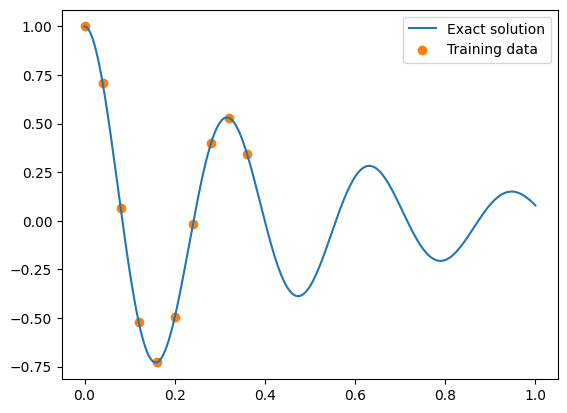

In [5]:
# Parameters for the under-damped harmonic oscillator state
d, w0 = 2, 20

# Define the domain inputs
x = torch.linspace(0, 1, 500).view(-1, 1)

# Get the target solution of the harmonic oscillator function
y = oscillator(d, w0, x).view(-1, 1)

print(x.shape, y.shape)

# Get points at intervals
x_data = x[0:200:20]
y_data = y[0:200:20]
print(x_data.shape, y_data.shape)

plt.figure()
plt.plot(x, y, label="Exact solution")
plt.scatter(x_data, y_data, color="tab:orange", label="Training data")
plt.legend()
plt.show()

In [6]:
def plot_result(title, x, y, x_data, y_data, y_out):
    plt.figure(figsize=(4, 2))
    plt.plot(x, y, color="grey", linewidth=2, alpha=0.8, label="Exact solution")
    plt.plot(
        x,
        y_out,
        color="tab:blue",
        linewidth=2,
        alpha=0.8,
        label="Neural network prediction",
    )
    plt.scatter(
        x_data, y_data, s=60, color="tab:orange", alpha=0.4, label="Training data"
    )

    plt.xlim(-0.05, 1.05)
    plt.ylim(-1.1, 1.1)
    plt.title(title)
    plt.axis(False)

## Naive Neural Network

The naive neural network is trained with just the Mean Squared Error (MSE) loss function.


100%|██████████| 25000/25000 [00:06<00:00, 4108.60it/s]


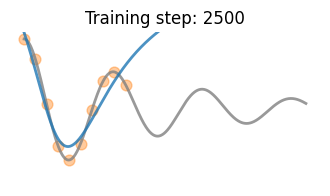

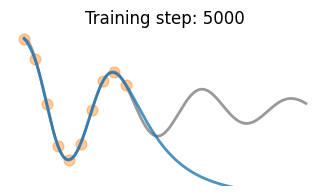

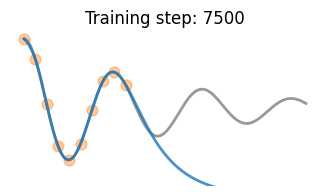

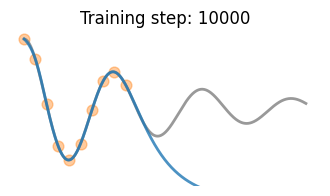

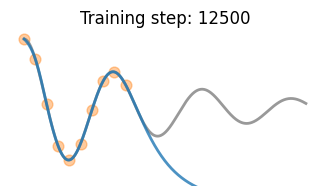

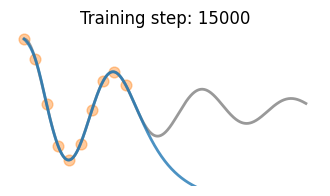

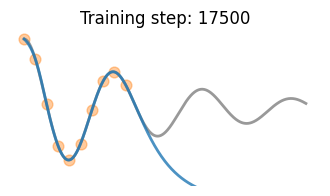

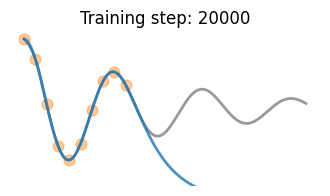

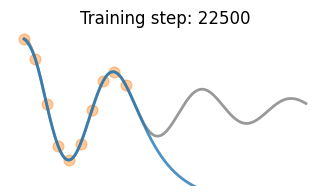

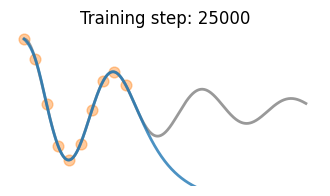

In [9]:
epochs = 25000
lr = 1e-4

naive_model = HarmonicOscillatorNN(
    input_features=1, output_features=1, hidden_features=32, num_layers=3
).to(device)
optimizer = optim.Adam(params=naive_model.parameters(), lr=lr)
loss_fn = nn.MSELoss()

x_data, y_data = x_data.to(device), y_data.to(device)

for i in tqdm(range(epochs)):
    optimizer.zero_grad()
    y_out = naive_model(x_data)

    loss = loss_fn(y_out, y_data)
    loss.backward()
    optimizer.step()

    if (i + 1) % (epochs / 10) == 0:
        y_out = naive_model(x).detach()

        plot_result(f"Training step: {i + 1}", x, y, x_data, y_data, y_out)

## Physics-Informed Neural Network (PINN)

Add the **underlying differential equation** as the **physics loss** to the MSE loss function from the naive neural network.


100%|██████████| 25000/25000 [00:18<00:00, 1386.02it/s]


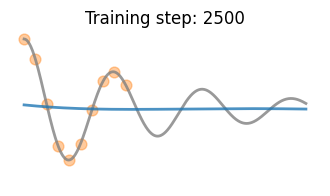

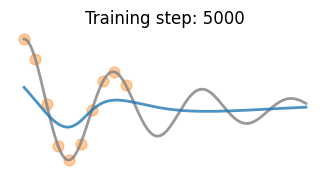

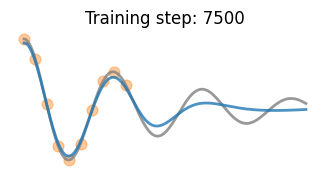

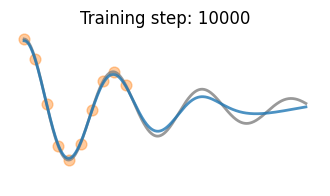

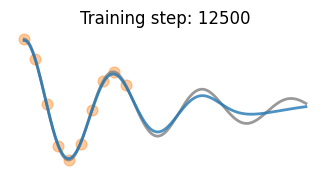

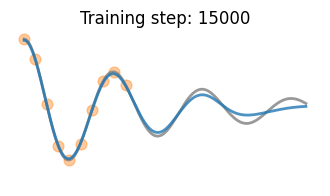

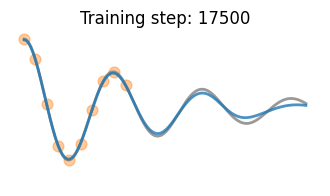

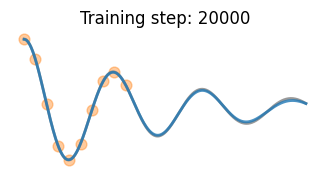

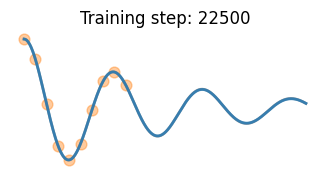

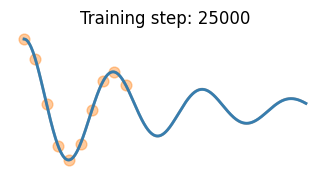

In [10]:
x_physics = (
    torch.linspace(0, 1, 30).view(-1, 1).requires_grad_(True)
)  # Sample locations over the domain

mu = torch.tensor(2 * d)
k = torch.tensor(w0**2)

epochs = 25000
lr = 1e-4

pinn_model = HarmonicOscillatorNN(
    input_features=1, output_features=1, hidden_features=32, num_layers=3
).to(device)
optimizer = optim.Adam(params=pinn_model.parameters(), lr=lr)
loss_fn = nn.MSELoss()

for i in tqdm(range(epochs)):
    optimizer.zero_grad()

    # Compute the data loss
    y_out = pinn_model(x_data)
    loss1 = loss_fn(y_out, y_data)

    # Compute the physics loss
    y_physics_out = pinn_model(x_physics)

    # Compute the first order derivative (dy/dx)
    dx = torch.autograd.grad(
        y_physics_out, x_physics, torch.ones_like(y_physics_out), create_graph=True
    )[0]

    # Compute the second order derivative (d^2y/dx^2)
    dx2 = torch.autograd.grad(dx, x_physics, torch.ones_like(dx), create_graph=True)[0]

    # Compute the residual of the 1D harmonic oscillator differential equation
    physics = dx2 + mu * dx + k * y_physics_out

    loss2 = (1e-4) * torch.mean(physics**2)

    # Add the loss terms and backpropagate the joint loss function
    loss = loss1 + loss2
    loss.backward()
    optimizer.step()

    if (i + 1) % (epochs / 10) == 0:
        y_out = pinn_model(x).detach()

        plot_result(f"Training step: {i + 1}", x, y, x_data, y_data, y_out)